A script used for temporal check for LOO validation

In [5]:
import numpy as np
import xarray as xr

# True data ALL
path = '/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/paleo-emu/examples/training_data/'
modhighice_all_Y=path+'training_data_lowmodice_temp_formatted.nc'

ds = xr.open_dataset(modhighice_all_Y)
Y_true = ds['var'].values  # assuming 'var' is the variable name in the netCDF file  
latitudes = ds['lat'].values
longitudes = ds['lon'].values

In [6]:
Y_pred0 = xr.open_dataset('prediction_data/0case_LOO_emulation_predictions.nc')['temperature'].values
Y_pred1 = xr.open_dataset('prediction_data/1case_LOO_emulation_predictions.nc')['temperature'].values
Y_pred2 = xr.open_dataset('prediction_data/2case_LOO_emulation_predictions.nc')['temperature'].values
Y_pred3 = xr.open_dataset('prediction_data/3case_LOO_emulation_predictions.nc')['temperature'].values
Y_pred4 = xr.open_dataset('prediction_data/4case_LOO_emulation_predictions.nc')['temperature'].values

In [7]:
lat_weights = np.cos(np.deg2rad(latitudes))
lat_weights /= lat_weights.mean()
weights_2d = np.tile(lat_weights[:, np.newaxis], (1, len(longitudes)))
def weighted_rmse(y_true, y_pred, weights):
    """Calculate the weighted RMSE between true and predicted values."""
    mse = np.average((y_true - y_pred) ** 2, weights=weights)
    return np.sqrt(mse)
# global average RMSE
Y_pred0 = np.squeeze(Y_pred0)
Y_pred1 = np.squeeze(Y_pred1)
Y_pred2 = np.squeeze(Y_pred2)
Y_pred3 = np.squeeze(Y_pred3)
Y_pred4 = np.squeeze(Y_pred4)
rmse0 = weighted_rmse(Y_true[0,:,:], Y_pred0, weights_2d)
rmse1 = weighted_rmse(Y_true[1,:,:], Y_pred1, weights_2d)
rmse2 = weighted_rmse(Y_true[2,:,:], Y_pred2, weights_2d)
rmse3 = weighted_rmse(Y_true[3,:,:], Y_pred3, weights_2d)
rmse4 = weighted_rmse(Y_true[4,:,:], Y_pred4, weights_2d)

print("old rmse are RMSE for cases are: 0.18148759485184296, 0.13722311336015486, 0.12181980876116005, 0.15586159448569947, 0.14278639458967185")
print(f"RMSE for cases are: {rmse0}, {rmse1}, {rmse2}, {rmse3}, {rmse4}")

old rmse are RMSE for cases are: 0.18148759485184296, 0.13722311336015486, 0.12181980876116005, 0.15586159448569947, 0.14278639458967185
RMSE for cases are: 0.18158552852527998, 0.13718231979165052, 0.12373609178242043, 0.1561327068713743, 0.14293360986206263


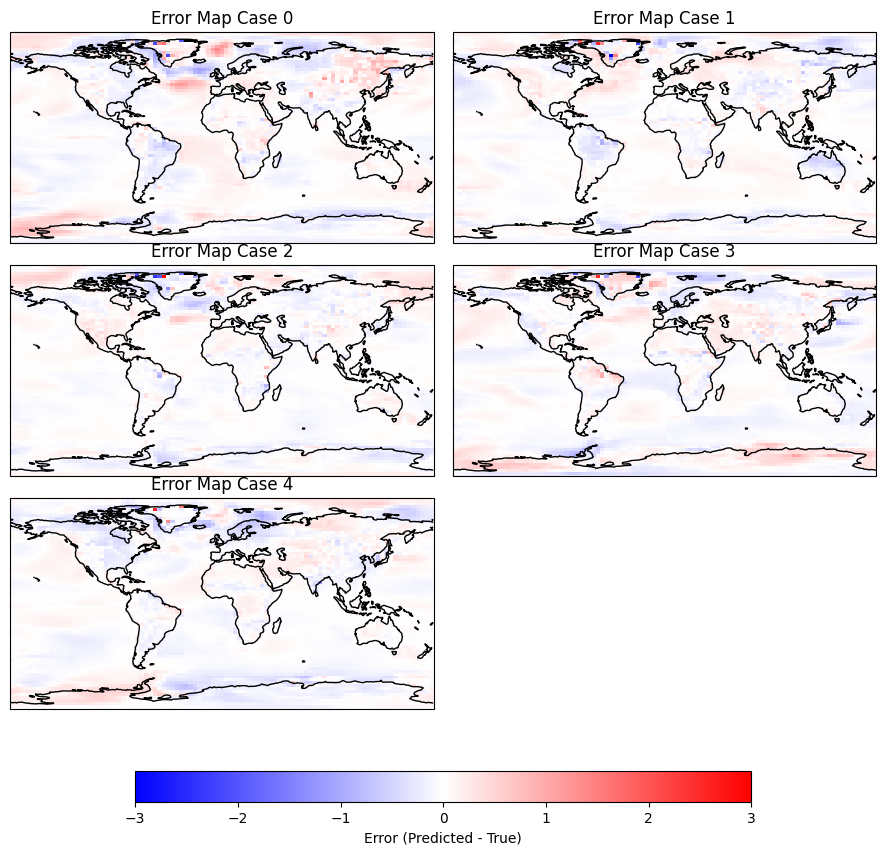

In [28]:
# plot maps of errors
import matplotlib.pyplot as plt
error0 = Y_pred0 - Y_true[0,:,:]
error1 = Y_pred1 - Y_true[1,:,:]
error2 = Y_pred2 - Y_true[2,:,:]
error3 = Y_pred3 - Y_true[3,:,:]
error4 = Y_pred4 - Y_true[4,:,:]
error0=error0[::-1,:]  # flip latitudes for plotting
error1=error1[::-1,:]
error2=error2[::-1,:]
error3=error3[::-1,:]
error4=error4[::-1,:]
import cartopy.crs as ccrs
fig, axs = plt.subplots(3, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
vmin = -3
vmax = 3

for i, (ax, error, title) in enumerate(zip(
    axs.flatten(), [error0, error1, error2, error3, error4],
    ['Error Map Case 0', 'Error Map Case 1', 'Error Map Case 2', 'Error Map Case 3', 'Error Map Case 4']
)):
    im = ax.pcolormesh(longitudes, latitudes, error, cmap='bwr', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# Remove the unused subplot (bottom right)
axs[2, 1].axis('off')

fig.subplots_adjust(wspace=-0.6, hspace=0.1)
cbar = fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.04, pad=0.08, label='Error (Predicted - True)')
plt.show()